I AM IMPLEMENTING THIS SMALL PROJECT TO LEARN ABOUT PERSISTENCE IN LANGGRAPH

In [16]:
#imports
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.runnables import RunnableConfig
from typing import Annotated, TypedDict
from operator import add

In [17]:
#Defining State Schema
class State(TypedDict):
    foo: str
    bar: Annotated[list[str], add]

In [18]:
#Defining Nodes
def Node_A(state: State):
    return {"foo": "a", "bar": ["a"]}

def Node_B(state: State):
    return {"foo": "b", "bar": ["b"]}

In [19]:
#Creating the Graph from Schema
workflow = StateGraph(State)

#Adding Nodes
workflow.add_node(Node_A)
workflow.add_node(Node_B)

#Adding Edges
workflow.add_edge(START, "Node_A")
workflow.add_edge("Node_A", "Node_B")
workflow.add_edge("Node_B", END)

#Adding Persistent Memory
checkpointer = InMemorySaver()
graph = workflow.compile(checkpointer = checkpointer)

config: RunnableConfig = {"configurable": {"thread_id": "1"}}
graph.invoke({"foo": "", "bar": []}, config)

{'foo': 'b', 'bar': ['a', 'b']}

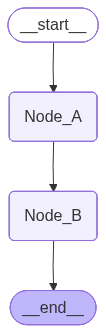

In [20]:
from IPython.display import display, Image
display(Image(graph.get_graph().draw_mermaid_png()))

In [23]:
from langgraph.checkpoint.base import get_checkpoint_id
get_checkpoint_id(config)

'1ef663ba-28fe-6528-8002-5a559208592c'

In [25]:
# get the latest state snapshot
config = {"configurable": {"thread_id": "1"}}
graph.get_state(config)

#get a state snapshot for a specific checkpoint_id
config = {"configurable": {"thread_id": "1", "checkpoint_id": "1ef663ba-28fe-6528-8002-5a559208592c"}}
graph.get_state(config)

StateSnapshot(values={}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1ef663ba-28fe-6528-8002-5a559208592c'}}, metadata=None, created_at=None, parent_config=None, tasks=(), interrupts=())

In [26]:
#getting the state history
config = {"configurable":{"thread_id": "1"}}
list(graph.get_state_history(config))

[StateSnapshot(values={'foo': 'b', 'bar': ['a', 'b']}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f151e82-6510-60ce-8002-5544ffc14004'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-05-17T12:01:34.230112+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f151e82-6505-6af3-8001-1abb8fcabe57'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'foo': 'a', 'bar': ['a']}, next=('Node_B',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f151e82-6505-6af3-8001-1abb8fcabe57'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-05-17T12:01:34.225864+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f151e82-6501-6159-8000-9b5af55a1330'}}, tasks=(PregelTask(id='b6455656-c744-1abb-20ce-f4e8385a28b1', name='Node_B', path=('__pregel_pull', 'Node_B'), error=None, interrupts

In [27]:
#finding a specific checkpoint
history = list(graph.get_state_history(config))

#Find the checkpoint before a specific node executed
before_node_b = next(s for s in history if s.next == ("node_b",))

#Finding the checkpoint by step number
step_2 = next(s for s in history if s.metadata["step"] == 2)

#Find checkpoints created by update_state
forks = [s for s in history if s.metadata["source"] == "update"]

#Finding the checkpoint where an interrupted occured
interrupted = next(
    s for s in history
    if s.tasks and any(t.interrupts for t in s.tasks)
)

StopIteration: 